In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler


from statsmodels.api import OLS, add_constant


data = pd.read_csv('data.csv')

categorical_vars = ['Company', 'Country', 'Data']
continuous_vars = ['Income', 'Revenue', 'StockPrice2023', 'StockPrice2024', 'NumberOfUsers']

In [79]:
#1
#Variables Categóricas: calcular la moda y el numero de repeticiones
categorical_stats = {}
for var in categorical_vars:
    mode_value = data[var].mode()[0]  # Moda
    mode_count = data[var].value_counts().iloc[0]  # Frecuencia de la moda
    categorical_stats[var] = {'Moda': mode_value, 'Repeticiones': mode_count}
    print(f"{var}: Moda = {mode_value}, Repeticiones = {mode_count}")

Company: Moda = AMD, Repeticiones = 1
Country: Moda = USA, Repeticiones = 36
Data: Moda = Train, Repeticiones = 38


In [80]:
#Variables continuas: calcular media, mediana, cuartiles y desviación estándar.
continuous_stats = data[continuous_vars].describe().T
continuous_stats['median'] = data[continuous_vars].median()
print(continuous_stats)
print("=================================")
for var in continuous_vars:
    print(f"\nVariable: {var}")
    print(f"Media: {data[var].mean():.2f}")
    print(f"Mediana: {data[var].median():.2f}")
    print(f"Cuartiles: {data[var].quantile([0.25, 0.5, 0.75]).to_dict()}")
    print(f"Desviación estándar: {data[var].std():.2f}")

                count    mean         std   min    25%    50%     75%     max  \
Income           50.0    8.78   15.770406  -1.0   2.00    3.0    7.75    80.0   
Revenue          50.0   52.28   89.850679   1.0   8.25   27.0   50.00   470.0   
StockPrice2023   50.0  115.94  139.899295   9.0  31.25   62.5  147.50   700.0   
StockPrice2024   50.0  121.42  144.306235  10.0  33.25   66.5  155.00   720.0   
NumberOfUsers    50.0  360.30  548.440656  50.0  86.25  150.0  348.75  3000.0   

                median  
Income             3.0  
Revenue           27.0  
StockPrice2023    62.5  
StockPrice2024    66.5  
NumberOfUsers    150.0  

Variable: Income
Media: 8.78
Mediana: 3.00
Cuartiles: {0.25: 2.0, 0.5: 3.0, 0.75: 7.75}
Desviación estándar: 15.77

Variable: Revenue
Media: 52.28
Mediana: 27.00
Cuartiles: {0.25: 8.25, 0.5: 27.0, 0.75: 50.0}
Desviación estándar: 89.85

Variable: StockPrice2023
Media: 115.94
Mediana: 62.50
Cuartiles: {0.25: 31.25, 0.5: 62.5, 0.75: 147.5}
Desviación estándar: 1

In [81]:
# Transformar la variable país de origen, y asignar el valor otro a los países que sean diferente de China, Japan y USA.
def transform_country(country):
    if country not in ['China', 'Japan', 'USA']:
        return 'Other'
    return country

data['Country_Transformed'] = data['Country'].apply(transform_country)
print(data[['Country', 'Country_Transformed']].drop_duplicates())

        Country Country_Transformed
0           USA                 USA
14      Germany               Other
20       Canada               Other
27        China               China
29        Japan               Japan
30  South Korea               Other
35  Netherlands               Other
41           UK               Other
49       Sweden               Other


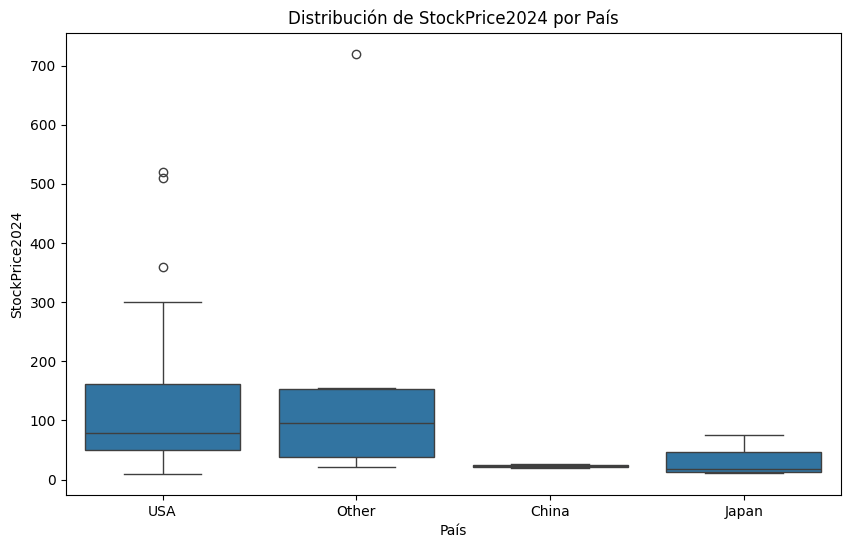

In [82]:
#Crear boxplot donde la variable objetivo es StockPrice2024 y el X: pais
plt.figure(figsize=(10, 6))
sns.boxplot(x='Country_Transformed', y='StockPrice2024', data=data)
plt.title('Distribución de StockPrice2024 por País')
plt.xlabel('País')
plt.ylabel('StockPrice2024')
plt.show()

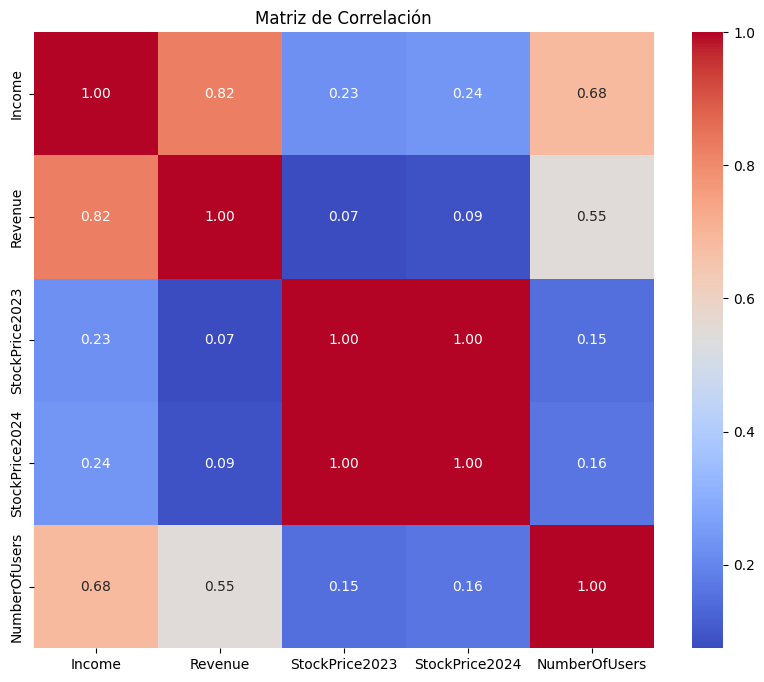

In [83]:
#Crear matriz de correlación. Cual es la variable que más ayuda a predecir StockPrice2024?
correlation_matrix = data[continuous_vars].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlación')
plt.show()


In [84]:
# la que tiene el 1 es StockPrice2023 seria esa

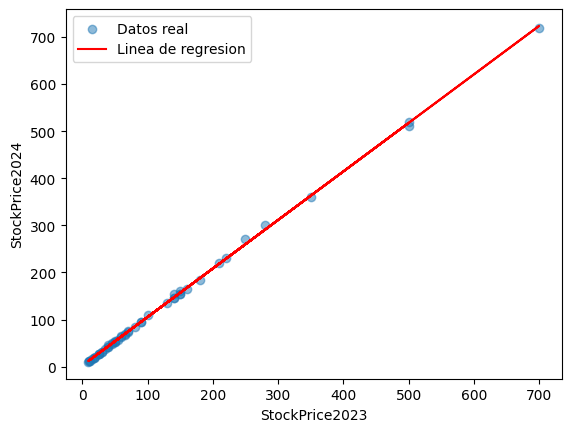

B0: 2.377746852221918, B1: 1.0302683583716228
Numerador B1: 922674.3157894737, Denominador: 895566.9736842104
MSE Train: 443.54614909673495, R² Train: 0.9995360837402563
MSE Test: 30.68685183832625, R² Test: 0.9985818073833845


In [85]:
#2
def calcular_correlacion(x, y):
    media_x, media_y = np.mean(x), np.mean(y)
    num = np.sum((x - media_x) * (y - media_y))  
    den_x = np.sqrt(np.sum((x - media_x) ** 2))  # DE de X
    den_y = np.sqrt(np.sum((y - media_y) ** 2))  # DE de Y
    return num / (den_x * den_y)

# Cojo la mejor correlacion
correlaciones = {var: calcular_correlacion(data[var], data['StockPrice2024']) for var in continuous_vars if var != 'StockPrice2024'}
best_x = max(correlaciones, key=lambda k: abs(correlaciones[k]))
X, Y = data[best_x].tolist(), data['StockPrice2024'].tolist()

train_data = data[data['Data'] == 'Train']
test_data = data[data['Data'] == 'Test']

X_train = train_data['StockPrice2023'].values
Y_train = train_data['StockPrice2024'].values

X_test = test_data['StockPrice2023'].values
Y_test = test_data['StockPrice2024'].values

X_train_mean = X_train.mean()
Y_train_mean = Y_train.mean()
numerador_B1 = np.dot(X_train - X_train_mean, Y_train - Y_train_mean)
denominador_B1 = np.dot(X_train - X_train_mean, X_train - X_train_mean)
B1 = numerador_B1 / denominador_B1
B0 = Y_train_mean - B1 * X_train_mean

plt.scatter(X, Y, alpha=0.5, label="Datos real")  
plt.plot(X, [B0 + B1 * x for x in X], color='red', label="Linea de regresion") 
plt.xlabel(best_x)
plt.ylabel("StockPrice2024")
plt.legend()
plt.show()

#train/test
def train_test_split_manual(X, Y, test_size=0.2):
    n_test = int(len(X) * test_size)
    X_train, X_test = X[:-n_test], X[-n_test:]
    Y_train, Y_test = Y[:-n_test], Y[-n_test:]
    return X_train, X_test, Y_train, Y_test

X_train, X_test, Y_train, Y_test = train_test_split_manual(X, Y)

# M mse y R
def calcular_metricas(X, Y, B0, B1):
    Y_pred = [B0 + B1 * x for x in X] 
    mse = sum((Y[i] - Y_pred[i]) ** 2 for i in range(len(Y))) 
    ss_total = sum((yi - sum(Y) / len(Y)) ** 2 for yi in Y)  
    ss_residual = sum((Y[i] - Y_pred[i]) ** 2 for i in range(len(Y)))  
    r2 = 1 - (ss_residual / ss_total) 
    return mse, r2

# M tes/train
mse_train, r2_train = calcular_metricas(X_train, Y_train, B0, B1)
mse_test, r2_test = calcular_metricas(X_test, Y_test, B0, B1)


print(f"B0: {B0}, B1: {B1}")
print(f"Numerador B1: {numerador_B1}, Denominador: {denominador_B1}")

print(f"MSE Train: {mse_train}, R² Train: {r2_train}")
print(f"MSE Test: {mse_test}, R² Test: {r2_test}")



In [86]:
#3
data['Country_Transformed'] = data['Country'].apply(transform_country)

data = pd.get_dummies(data, columns=['Country_Transformed'], drop_first=True)
data = data.apply(pd.to_numeric, errors='coerce')

X = data[['Income', 'Revenue', 'StockPrice2023', 'NumberOfUsers'] + 
         [col for col in data.columns if col.startswith('Country_Transformed_')]]
Y = data['StockPrice2024']

X = X.dropna()
Y = Y.loc[X.index]  

#(80% - 20%)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, Y_train)

Y_train_pred = model.predict(X_train)
Y_test_pred = model.predict(X_test)

r2_train = r2_score(Y_train, Y_train_pred)
r2_test = r2_score(Y_test, Y_test_pred)
mse_train = mean_squared_error(Y_train, Y_train_pred)
mse_test = mean_squared_error(Y_test, Y_test_pred)

X_train_const = add_constant(X_train)  
X_train_const = X_train_const.astype(float)

ols_model = OLS(Y_train, X_train_const).fit()

print("R² en entrenamiento:", r2_train)
print("R² en test:", r2_test)
print("MSE en entrenamiento:", mse_train)
print("MSE en test:", mse_test)
#Variables más significativas para predecir:
print(ols_model.pvalues[ols_model.pvalues < 0.05].sort_values()) #StockPrice2024

R² en entrenamiento: 0.9998319506557503
R² en test: 0.9990937113344508
MSE en entrenamiento: 3.9857821633369914
MSE en test: 2.825309600416232
StockPrice2023    1.067600e-60
NumberOfUsers     8.519491e-04
Revenue           6.442177e-03
dtype: float64


In [87]:
#4
X = data[categorical_vars + continuous_vars]
y = data["StockPrice2024"]

# train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Preprocesamiento: convertir variables categóricas en dummies y escalar numéricas
preprocessor = ColumnTransformer(transformers=[
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_vars),
    ("num", StandardScaler(), continuous_vars)
])

#crear pipeleine
knn_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", KNeighborsRegressor(n_neighbors=3))
])
knn_pipeline.fit(X_train, y_train)


y_train_pred = knn_pipeline.predict(X_train)
y_test_pred = knn_pipeline.predict(X_test)


r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)
mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)

print(f"R² en training: {r2_train:.4f}")
print(f"MSE en training: {mse_train:.2f}")
print(f"R² en test: {r2_test:.4f}")
print(f"MSE en test: {mse_test:.2f}")

if "Roku" in data["Company"].values:
    roku_index = data[data["Company"] == "Roku"].index[0]
    X_transformed = knn_pipeline.named_steps["preprocessor"].transform(X)
    distances, indices = knn_pipeline.named_steps["model"].kneighbors(X_transformed[roku_index].reshape(1, -1))
    
    neighbors = data.iloc[indices[0]]["Company"].values
    print(f"Vecinos más cercanos para Roku: {neighbors}")
else:
    print("Roku no está en el dataset.")

R² en training: 0.9372
MSE en training: 1489.69
R² en test: 0.9267
MSE en test: 228.57
Roku no está en el dataset.


In [89]:
#5
#¿Cuál modelo funciona mejor para predecir la variable objetivo y por qué?
#En este caso que no tienen una relacion no lineal compleja es mejor la regresion lineal si no dira que KNN por el simple hecho que seria mas optimo

#Cuál es la variable más importante para la predicción y por qué?
# por la matriz de correlacion seria entre Revenue y StockPrice2023

In [90]:
# Definimos las calificaciones y sus respectivos pesos
nota_1 = 3.5  # nota en el 60%
peso_1 = 0.60  # peso del 60%

nota_2 = 30  # nota en el 40%
peso_2 = 0.40  # peso del 40%

# Calculamos la nota final
nota_final = (nota_1 * peso_1) + (nota_2 * peso_2)
nota_final


14.1